<a href="https://colab.research.google.com/github/Rojakarilakshmiprasanna/11239A077_OPENCV_LAB_OBSERVATION/blob/main/EXPERIMENT_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opencv-python-headless

In [ ]:
import cv2
print(cv2.__version__)

4.13.0


Saving strawberry_rotten_005.jpg (3).jpg to strawberry_rotten_005.jpg (3) (1).jpg


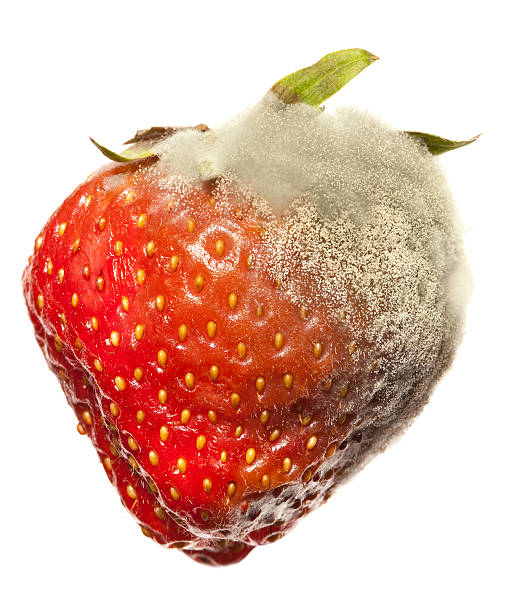

In [ ]:
from google.colab import files
import cv2
from google.colab.patches import cv2_imshow

# Upload file
uploaded = files.upload()

# Get file name automatically
filename = list(uploaded.keys())[0]

# Read and display
img = cv2.imread(filename)

if img is None:
    print("Error loading image")
else:
    cv2_imshow(img)

Saving dance-dancing.gif to dance-dancing (3).gif
Uploaded GIF: dance-dancing (3).gif


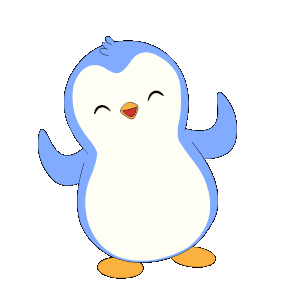

In [ ]:
# Step 1: Upload GIF
from google.colab import files
uploaded = files.upload()  # Upload your .gif file

# Step 2: Get the uploaded file name
gif_filename = list(uploaded.keys())[0]
print("Uploaded GIF:", gif_filename)

# Step 3: Display GIF
from IPython.display import Image, display

display(Image(filename=gif_filename))

In [ ]:
# Step 1: Upload your MP4 video
from google.colab import files
uploaded = files.upload()  # Upload your .mp4 file

# Step 2: Get the uploaded file name
video_filename = list(uploaded.keys())[0]
print("Uploaded video:", video_filename)

# Step 3: Display video in Colab using HTML
from IPython.display import HTML

HTML(f"""
<video width="640" height="480" controls>
  <source src="{video_filename}" type="video/mp4">
  Your browser does not support the video tag.
</video>
""")

Saving 3-01Hara Hara Shankara Jaya Jaya Shankara10 years agoyoutube.com.url to 3-01Hara Hara Shankara Jaya Jaya Shankara10 years agoyoutube.com.url
Uploaded video: 3-01Hara Hara Shankara Jaya Jaya Shankara10 years agoyoutube.com.url


In [ ]:
# Step 1: Import libraries
from IPython.display import display, Javascript
from google.colab.output import eval_js
import cv2
import numpy as np
from base64 import b64decode

# Step 2: JavaScript to capture image from webcam
def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize output
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getTracks().forEach(track => track.stop());
      div.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
  ''')

  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])

  with open(filename, 'wb') as f:
    f.write(binary)

  return filename

# Step 3: Capture and display image
image_file = take_photo()

# Step 4: Show image using OpenCV
from google.colab.patches import cv2_imshow
img = cv2.imread(image_file)
cv2_imshow(img)

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
import cv2
import numpy as np
from base64 import b64decode

def take_photo(filename='captured_photo.jpg', quality=0.8):
    js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const captureButton = document.createElement('button');
      captureButton.textContent = 'Capture';
      div.appendChild(captureButton);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      await new Promise((resolve) => captureButton.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getTracks().forEach(track => track.stop());
      div.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

# Capture photo and save
filename = take_photo()

# Display saved image using OpenCV
from google.colab.patches import cv2_imshow
img = cv2.imread(filename)
cv2_imshow(img)
print(f"Image saved as {filename}")